In [32]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV,KFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score,root_mean_squared_error

In [33]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/sklearn-ml-projects/human_cognitive_load/human_cognitive.csv')

In [34]:
# Dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   task_id               150000 non-null  int64  
 1   task_difficulty       150000 non-null  int64  
 2   reaction_time_ms      150000 non-null  float64
 3   accuracy_percent      150000 non-null  float64
 4   error_rate            150000 non-null  float64
 5   task_duration_sec     150000 non-null  float64
 6   heart_rate_bpm        150000 non-null  float64
 7   eye_blink_rate        150000 non-null  float64
 8   mental_fatigue_level  150000 non-null  int64  
 9   stress_level          150000 non-null  float64
 10  experience_level      150000 non-null  object 
 11  task_type             150000 non-null  object 
 12  work_environment      150000 non-null  object 
 13  time_of_day           150000 non-null  object 
 14  gender                150000 non-null  object 
 15  

,task_id,task_difficulty,reaction_time_ms,accuracy_percent,error_rate,task_duration_sec,heart_rate_bpm,eye_blink_rate,mental_fatigue_level,stress_level,cognitive_load_score
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,3.003513,650.388030,84.688555,0.199834,299.894898,77.999092,20.015487,2.995700,5.012264,2.424316
std,43301.414527,1.416378,119.649850,9.444953,0.120729,79.851210,9.963246,5.962994,1.413082,1.947844,0.762145
min,1.000000,1.000000,200.000000,43.944867,0.000303,60.000000,50.000000,5.000000,1.000000,1.000000,1.000000
25%,37500.750000,2.000000,569.787003,78.227610,0.106838,245.985254,71.243211,15.955320,2.000000,3.656214,1.870927
50%,75000.500000,3.000000,650.294795,84.975580,0.179698,300.291567,77.996177,19.998912,3.000000,5.000094,2.411632
75%,112500.250000,4.000000,731.013339,91.750319,0.271997,353.505538,84.715970,24.046524,4.000000,6.350177,2.959222
max,150000.000000,5.000000,1226.181747,100.000000,0.844917,661.919904,123.087466,46.648686,5.000000,10.000000,5.985438


In [35]:
# Null Check
df.isnull().sum()

,0
task_id,0
task_difficulty,0
reaction_time_ms,0
accuracy_percent,0
error_rate,0
task_duration_sec,0
heart_rate_bpm,0
eye_blink_rate,0
mental_fatigue_level,0
stress_level,0


# **Visualizing**

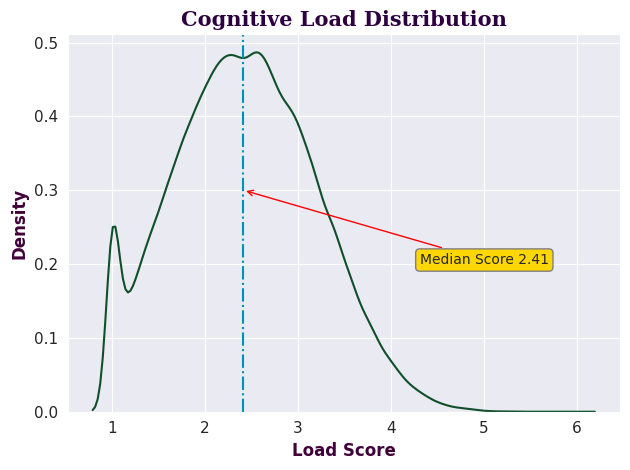

In [36]:
# Page Theme
sns.set_style('darkgrid')

# Kdeplot
ax = sns.kdeplot(x='cognitive_load_score',data=df,color='#104f29')

# Annotation
mid = df['cognitive_load_score'].median()
ax.axvline(mid,color='#008FB5',linestyle='-.')
ax.annotate(f'Median Score {round(mid,2)}',xy=(mid,0.3),xytext=(mid+1.9,0.2),arrowprops=dict(arrowstyle='->',color='red'),
           bbox= dict(facecolor='gold',edgecolor='grey',boxstyle='round'))

# Styling Title , Lables and Ticks
plt.title('Cognitive Load Distribution',fontweight='bold',fontsize=15,fontfamily='Serif',color='#2C0040')
plt.xlabel('Load Score',fontweight='bold',fontsize=12,color='#40003A')
plt.ylabel('Density',fontweight='bold',fontsize=12,color='#40003A')
ax.tick_params(labelsize=11)

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# The cognitive load score shows a right-skewed distribution.
# where most values lie in low to mid range, and higher load scores gradually decrease.
# Indicating that most tasks are manageable, while high cognitive load occurs in few cases.

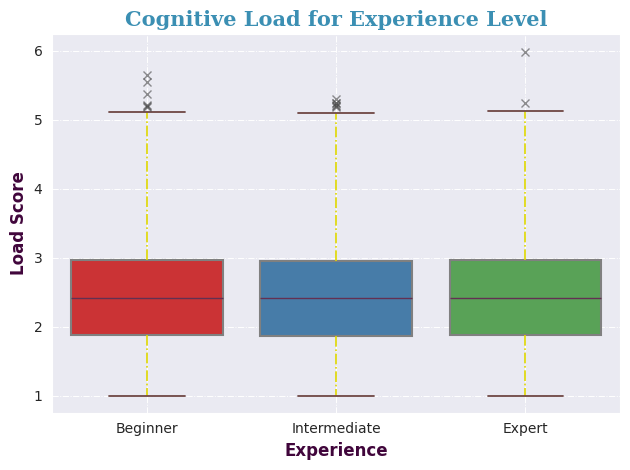

In [37]:
# Page Theme
sns.set_style('darkgrid')

# Bosplot
b = {'edgecolor':'grey','linewidth':1.5}
w = {'linestyle':'-.','color':'#DED700','linewidth':1.2}
c = {'color':'#6E4744','linewidth':1.3}
m = {'color':'#633052'}
f = {'marker':'x','alpha':0.6}
ax = sns.boxplot(x='experience_level',y='cognitive_load_score',data=df,hue='experience_level',palette='Set1',whis=2,
            patch_artist=True,boxprops=b,capprops=c,whiskerprops=w,medianprops=m,flierprops=f)

# Styling Title and Labels
plt.title('Cognitive Load for Experience Level',fontweight='bold',fontsize=15,color='#3B8FB3',fontfamily='Serif')
plt.xlabel('Experience',fontweight='bold',fontsize=12,color='#40053B')
plt.ylabel('Load Score',fontweight='bold',fontsize=12,color='#40053B')

# Page Layout
plt.grid(linewidth=0.7,linestyle='-.')
plt.tight_layout()
plt.show()

# Insights :
# Cognitive load decreases with higher experience levels.
# where beginners show a higher median load and larger variability compared to experts.

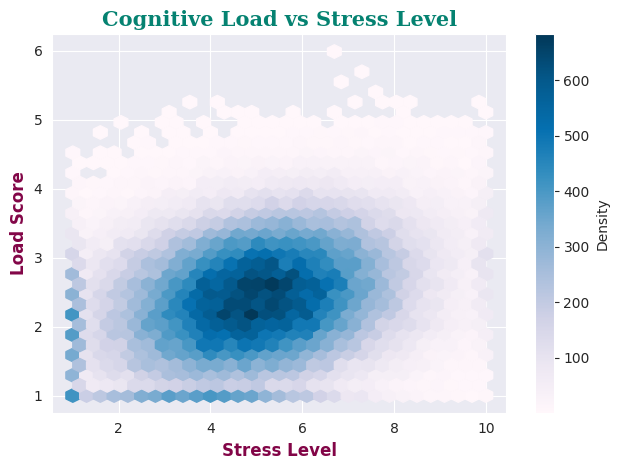

In [38]:
# Hexbin
plt.hexbin(x='stress_level',y='cognitive_load_score',data=df,reduce_C_function=np.mean,cmap='PuBu',gridsize=30,mincnt=1)
plt.colorbar(label='Density')

# Styling Title and Labels
plt.title('Cognitive Load vs Stress Level',fontweight='bold',fontsize=15,color='#058271',fontfamily='Serif')
plt.xlabel('Stress Level',fontweight='bold',fontsize=12,color='#820547')
plt.ylabel('Load Score',fontweight='bold',fontsize=12,color='#820547')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# The dense clusters suggest that stress is a strong and consistent predictor of cognitive load rather than a random effect.

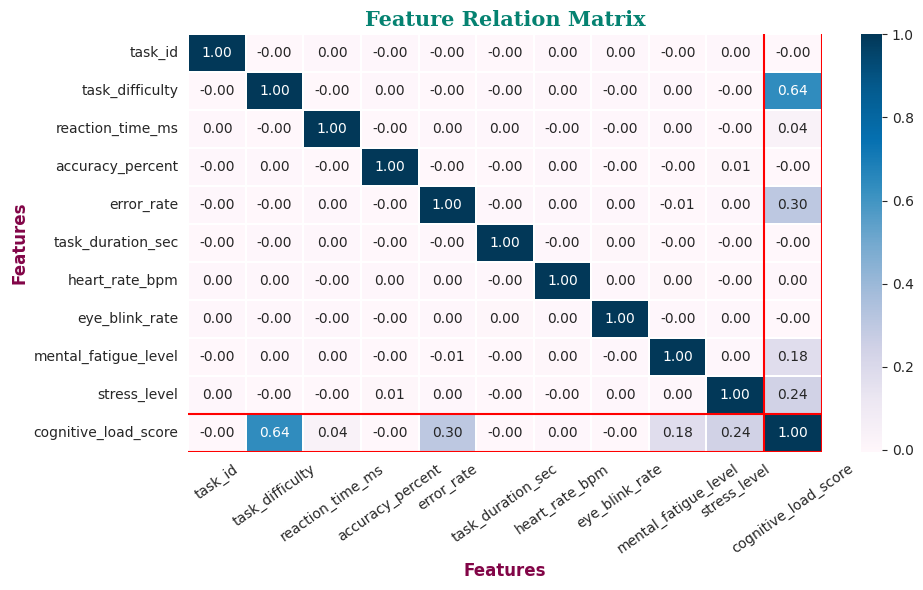

In [39]:
# Figure
plt.figure(figsize=(10,6))

# Feature Engineering
num_cols = df.select_dtypes(exclude='object').columns.to_list()
relation = df[num_cols].corr()
# Heatmap
c = {'shrink':1}
ax = sns.heatmap(relation,annot=True,fmt='.2f',cmap='PuBu',linewidth=0.2,cbar=c)

# Styling Title and Label
plt.title('Feature Relation Matrix',fontweight='bold',fontsize=15,color='#058271',fontfamily='Serif')
plt.xlabel('Features',fontweight='bold',fontsize=12,color='#820547')
plt.ylabel('Features',fontweight='bold',fontsize=12,color='#820547')
plt.xticks(rotation=35)

# Annotation
ax.hlines(y=10,xmin=0,xmax=11,color='r')
ax.hlines(y=11,xmin=0,xmax=11,color='r')
ax.vlines(x=10,ymin=0,ymax=11,color='r')
ax.vlines(x=11,ymin=0,ymax=11,color='r')

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# Correlation matrix shows task difficulty, stress level ,error_rate and mental fatigue have the strongest positive relationship with cognitive load.
# Other features show weaker correlations, indicating they have a smaller direct impact on cognitive load.

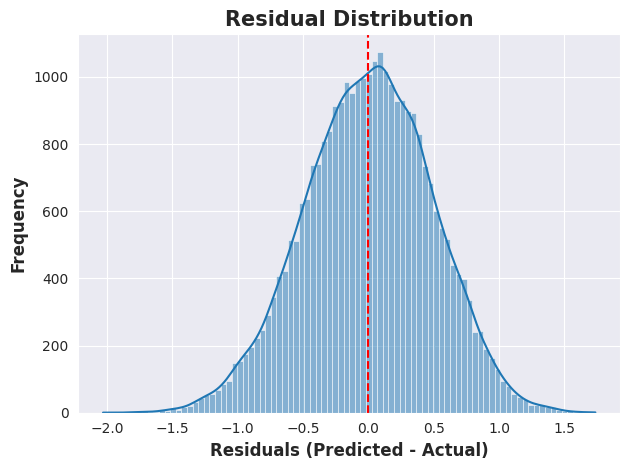

In [40]:
# Baseline Model
a = df.drop('cognitive_load_score',axis=1)
b = df['cognitive_load_score']
Xtrain,Xtest,ytrain,ytest = train_test_split(a,b,train_size=0.8)
ob_cols = Xtrain.select_dtypes('object').columns.to_list()
num_cols = Xtrain.select_dtypes(exclude='object').columns.to_list()
prep = ColumnTransformer([('Encode',OneHotEncoder(),ob_cols),('Scaling',StandardScaler(),num_cols)])
Xtrain_transform = prep.fit_transform(Xtrain)
Xtest_transform = prep.transform(Xtest)
lr = LinearRegression()
lr.fit(Xtrain_transform,ytrain)
prediction = lr.predict(Xtest_transform)
residual = prediction-ytest

# Page Theme
sns.set_style('darkgrid')

# Residual Plot
sns.histplot(residual,kde=True)

# Annotation
plt.axvline(0, color='red', linestyle='--')

# Styling Title and Label
plt.title("Residual Distribution",fontweight='bold',fontsize=15)
plt.xlabel("Residuals (Predicted - Actual)",fontweight='bold',fontsize=12)
plt.ylabel("Frequency",fontweight='bold',fontsize=12)

# Page Layout
plt.tight_layout()
plt.show()

# Insights
# Most of residuals are situated around zero, which means the model's predictions are close to the actual cognitive load scores
# Using regularized models like Ridge, Lasso, or ElasticNet helps handling , reducing overfitting, and stabilizing predictions.

# Model **Building**

In [ ]:
# Feature Engineering
Attention = df['heart_rate_bpm']/df['eye_blink_rate'] # Large value indicates higher concentration or stress
df.insert(14,'Attention',Attention)
stress_task= df['stress_level']*df['task_difficulty']
df.insert(15,'stress_task',stress_task)
fatigue_duration = df['mental_fatigue_level'] * df['task_duration_sec']
df.insert(16,'fatigue_duration',fatigue_duration)
performance= df['accuracy_percent'] - df['error_rate']
df.insert(17,'performance',performance)

In [41]:
# Train Test Split
Features = df.drop('cognitive_load_score',axis=1)
Target = df['cognitive_load_score']
Xtrain,Xtest,ytrain,ytest = train_test_split(Features,Target,train_size=0.8,random_state=20)

# Preprocessing
o_cols = Xtrain.select_dtypes('object').columns.to_list()
num_cols = Xtrain.select_dtypes(exclude='object').columns.to_list()
prep = ColumnTransformer([('Encode',OneHotEncoder(handle_unknown='ignore'),o_cols),('Scaling',StandardScaler(),num_cols)])

# Pipeline
pipe = Pipeline([('prep',prep),('model',Ridge())])

# Cross Validation
paras = {'model__alpha':[x for x in range(1,11)]}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
R_model = GridSearchCV(pipe,paras,cv=cv,verbose=2,n_jobs=-1)

# Model Training
R_model.fit(Xtrain,ytrain)

# I tried both Linear and Ridge regression.
# Since the dataset had low multicollinearity and mostly linear relationships, Ridge regularization did not change performance significantly.
# This indicates the features were already well-conditioned

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('Encode',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['experience_level',
                                                                          'task_type',
                                                                          'work_environment',
                                                                          'time_of_day',
                                                                          'gender']),
                                                                        ('Scaling',
                                                                         StandardScaler(),
                                                                         ['task_id',
                                                                          'task_difficulty',
                                                                          'reaction_time_ms',
                                                                          'accuracy_percent',
                                                                          'error_rate',
                                                                          'task_duration_sec',
                                                                          'heart_rate_bpm',
                                                                          'eye_blink_rate',
                                                                          'mental_fatigue_level',
                                                                          'stress_level'])])),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             verbose=2)

In [42]:
# Prediction
prediction = R_model.predict(Xtest)
# Scores
r_score = r2_score(ytest,prediction)
rmse = root_mean_squared_error(ytest,prediction)
print(f'Model R2 Score = {r_score} and Model RMSE score = {rmse}')

Model R2 Score = 0.5924164500628026 and Model RMSE score = 0.49098540052154943


In [43]:
# Saving a model
import joblib
joblib.dump(R_model,'Cognitive Load')

['Cognitive Load']